Load necessary library

In [1]:
# ============================================
# 1. IMPORT LIBRARIES
# ============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.svm import SVC
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    f1_score
)
import joblib

# optional: display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

Load data


In [2]:
# ============================================
# 2. LOAD DATA
# ============================================
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv"
df = pd.read_csv(url)

# preview
print("Shape:", df.shape)
display(df.head())

Shape: (2111, 17)


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [3]:
# ============================================
# 3. BASIC EDA
# ============================================
print("\n--- Info ---")
print(df.info())

print("\n--- Missing Values ---")
print(df.isna().sum())

print("\n--- Duplicates ---")
print("Duplicate rows:", df.duplicated().sum())

print("\n--- Descriptive Statistics (numeric) ---")
display(df.describe())

print("\n--- Descriptive Statistics (categorical) ---")
display(df.describe(include="object"))


--- Info ---
<class 'pandas.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   str    
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   str    
 5   FAVC                            2111 non-null   str    
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   str    
 9   SMOKE                           2111 non-null   str    
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   str    
 12  FAF                            

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000
mean,24.312600,1.701677,86.586058,2.419043,2.685628,2.008011,1.010298,0.657866
std,6.345968,0.093305,26.191172,0.533927,0.778039,0.612953,0.850592,0.608927
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,19.947192,1.630000,65.473343,2.000000,2.658738,1.584812,0.124505,0.000000
50%,22.777890,1.700499,83.000000,2.385502,3.000000,2.000000,1.000000,0.625350
75%,26.000000,1.768464,107.430682,3.000000,3.000000,2.477420,1.666678,1.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000



--- Descriptive Statistics (categorical) ---


C:\Users\EmmanuelAdewuyi\AppData\Local\Temp\ipykernel_25788\3459281608.py:17: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  display(df.describe(include="object"))


,Gender,family_history_with_overweight,FAVC,CAEC,SMOKE,SCC,CALC,MTRANS,NObeyesdad
count,2111,2111,2111,2111,2111,2111,2111,2111,2111
unique,2,2,2,4,2,2,4,5,7
top,Male,yes,yes,Sometimes,no,no,Sometimes,Public_Transportation,Obesity_Type_I
freq,1068,1726,1866,1765,2067,2015,1401,1580,351


NObeyesdad
Obesity_Type_I         351
Obesity_Type_III       324
Obesity_Type_II        297
Overweight_Level_I     290
Overweight_Level_II    290
Normal_Weight          287
Insufficient_Weight    272
Name: count, dtype: int64


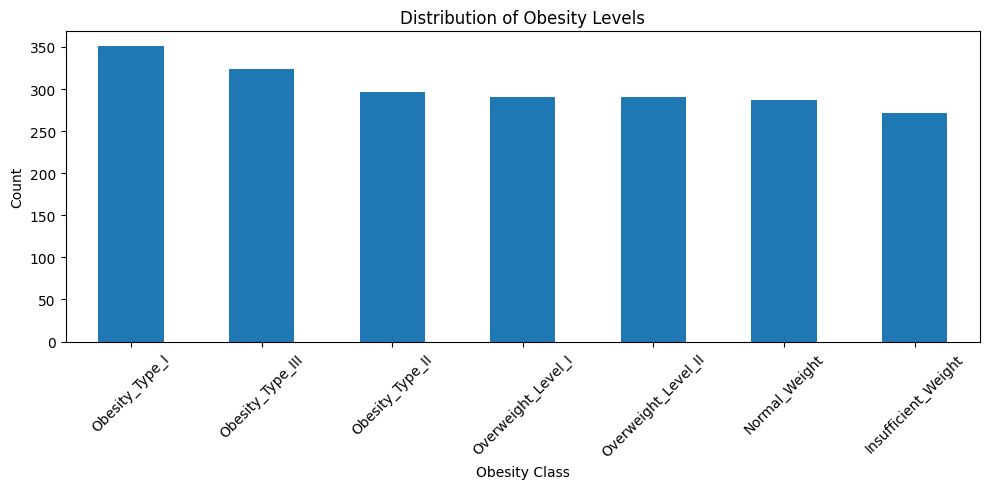

In [4]:
# ============================================
# 4. TARGET DISTRIBUTION
# ============================================
target_col = "NObeyesdad"

print(df[target_col].value_counts())

plt.figure(figsize=(10, 5))
df[target_col].value_counts().plot(kind="bar")
plt.title("Distribution of Obesity Levels")
plt.xlabel("Obesity Class")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [5]:
# ============================================
# 5. NUMERICAL AND CATEGORICAL COLUMNS
# ============================================
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()

# remove target from feature lists
if target_col in numeric_cols:
    numeric_cols.remove(target_col)
if target_col in categorical_cols:
    categorical_cols.remove(target_col)

print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)

Numeric columns: ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']
Categorical columns: ['Gender', 'family_history_with_overweight', 'FAVC', 'CAEC', 'SMOKE', 'SCC', 'CALC', 'MTRANS']


C:\Users\EmmanuelAdewuyi\AppData\Local\Temp\ipykernel_25788\980882111.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()


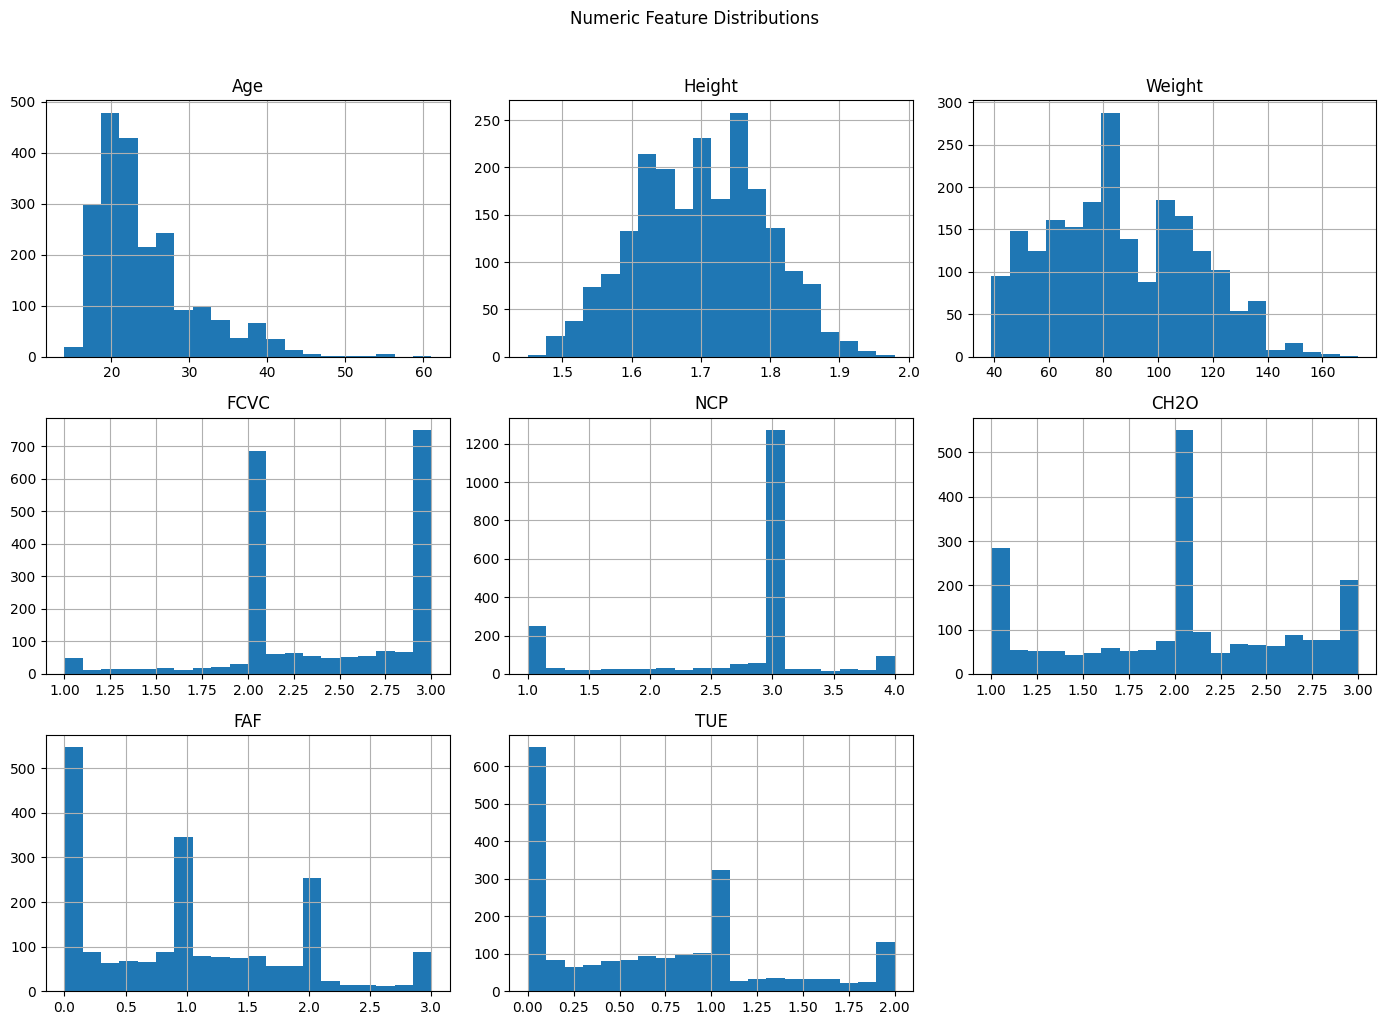

In [6]:
# ============================================
# 6. NUMERIC FEATURE DISTRIBUTIONS
# ============================================
df[numeric_cols].hist(figsize=(14, 10), bins=20)
plt.suptitle("Numeric Feature Distributions", y=1.02)
plt.tight_layout()
plt.show()

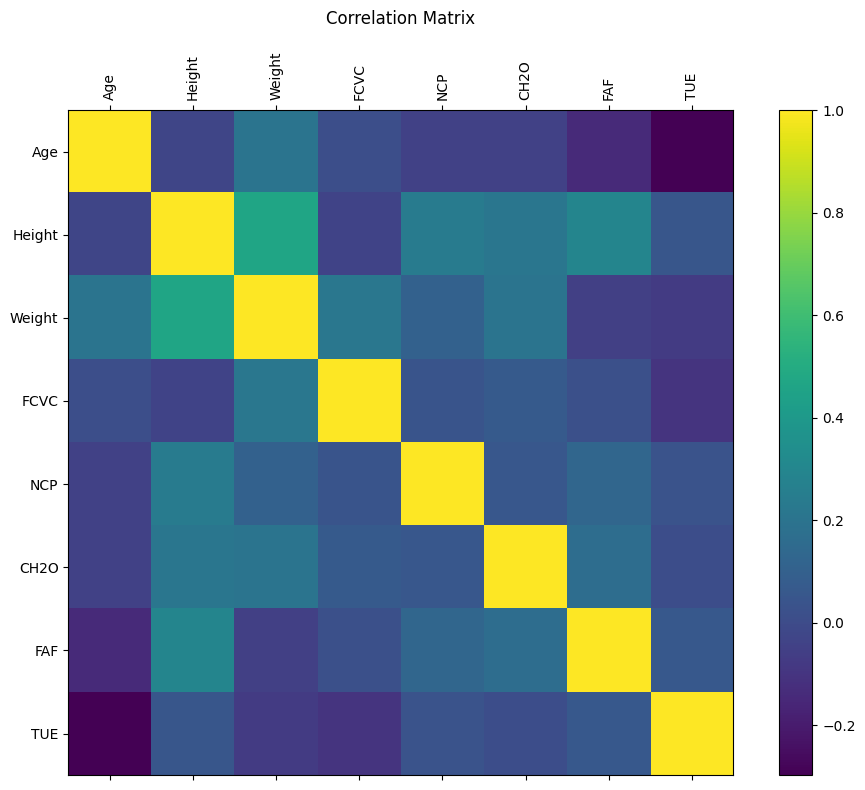

In [7]:
# ============================================
# 7. CORRELATION HEATMAP (MATPLOTLIB ONLY)
# ============================================
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
cax = ax.matshow(corr, interpolation='nearest')
fig.colorbar(cax)

ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=90)
ax.set_yticklabels(corr.columns)

plt.title("Correlation Matrix", pad=20)
plt.tight_layout()
plt.show()

In [8]:
# ============================================
# 8. CLASS-WISE SUMMARY OF NUMERIC FEATURES
# ============================================
display(df.groupby(target_col)[numeric_cols].mean())

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
NObeyesdad,,,,,,,,
Insufficient_Weight,19.783237,1.691117,49.906330,2.480788,2.914403,1.871281,1.250131,0.839459
Normal_Weight,21.738676,1.676585,62.155052,2.334495,2.738676,1.850174,1.247387,0.675958
Obesity_Type_I,25.884941,1.693804,92.870198,2.186050,2.431862,2.112218,0.986748,0.676743
Obesity_Type_II,28.233785,1.771795,115.305311,2.391284,2.744555,1.877658,0.971857,0.515186
Obesity_Type_III,23.495554,1.687559,120.941114,3.000000,3.000000,2.208493,0.664817,0.604623
Overweight_Level_I,23.417674,1.687836,74.266828,2.264631,2.504218,2.058725,1.056796,0.612992
Overweight_Level_II,26.996981,1.703748,82.085271,2.260578,2.495529,2.025133,0.958072,0.697275


In [9]:
# ============================================
# 9. REMOVE DUPLICATES IF ANY
# ============================================
df = df.drop_duplicates().reset_index(drop=True)
print("New shape after dropping duplicates:", df.shape)

New shape after dropping duplicates: (2087, 17)


In [10]:
# ============================================
# 10. SPLIT FEATURES AND TARGET
# ============================================
X = df.drop(columns=[target_col])
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (1669, 16)
X_test shape: (418, 16)


In [11]:
# ============================================
# 11. PREPROCESSING PIPELINES
# ============================================
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_cols),
    ("cat", categorical_transformer, categorical_cols)
])

In [12]:
# ============================================
# 12. BUILD FULL SVC PIPELINE
# ============================================
svc_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", SVC())
])

svc_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [13]:
# ============================================
# 13. BASELINE 5-FOLD CV
# ============================================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

baseline_scores = cross_val_score(
    svc_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

print("Baseline 5-Fold CV Accuracy Scores:", baseline_scores)
print("Baseline Mean CV Accuracy:", baseline_scores.mean())
print("Baseline Std CV Accuracy:", baseline_scores.std())

Baseline 5-Fold CV Accuracy Scores: [0.9011976  0.93113772 0.87724551 0.94011976 0.8978979 ]
Baseline Mean CV Accuracy: 0.9095196993400586
Baseline Std CV Accuracy: 0.023020206973205268


In [14]:
# ============================================
# 14. HYPERPARAMETER TUNING WITH 5-FOLD CV
# ============================================
param_grid = {
    "classifier__C": [0.1, 1, 10, 50],
    "classifier__kernel": ["linear", "rbf"],
    "classifier__gamma": ["scale", "auto", 0.01, 0.1]
}

grid_search = GridSearchCV(
    estimator=svc_pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best CV Accuracy:", grid_search.best_score_)

Fitting 5 folds for each of 32 candidates, totalling 160 fits
Best Parameters: {'classifier__C': 10, 'classifier__gamma': 'scale', 'classifier__kernel': 'linear'}
Best CV Accuracy: 0.9640520760281239


In [15]:
# ============================================
# 15. BEST MODEL
# ============================================
best_model = grid_search.best_estimator_
print(best_model)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'Height', 'Weight',
                                                   'FCVC', 'NCP', 'CH2O', 'FAF',
                                                   'TUE']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                         

In [16]:
# ============================================
# 16. TEST SET EVALUATION
# ============================================
y_pred = best_model.predict(X_test)

test_accuracy = accuracy_score(y_test, y_pred)
test_f1_weighted = f1_score(y_test, y_pred, average="weighted")

print("Test Accuracy:", test_accuracy)
print("Test Weighted F1:", test_f1_weighted)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Test Accuracy: 0.9569377990430622
Test Weighted F1: 0.9570756884319287

Classification Report:

                     precision    recall  f1-score   support

Insufficient_Weight       0.96      1.00      0.98        53
      Normal_Weight       1.00      0.95      0.97        57
     Obesity_Type_I       0.99      0.94      0.96        70
    Obesity_Type_II       0.95      1.00      0.98        60
   Obesity_Type_III       1.00      0.98      0.99        65
 Overweight_Level_I       0.91      0.91      0.91        55
Overweight_Level_II       0.88      0.91      0.90        58

           accuracy                           0.96       418
          macro avg       0.96      0.96      0.96       418
       weighted avg       0.96      0.96      0.96       418



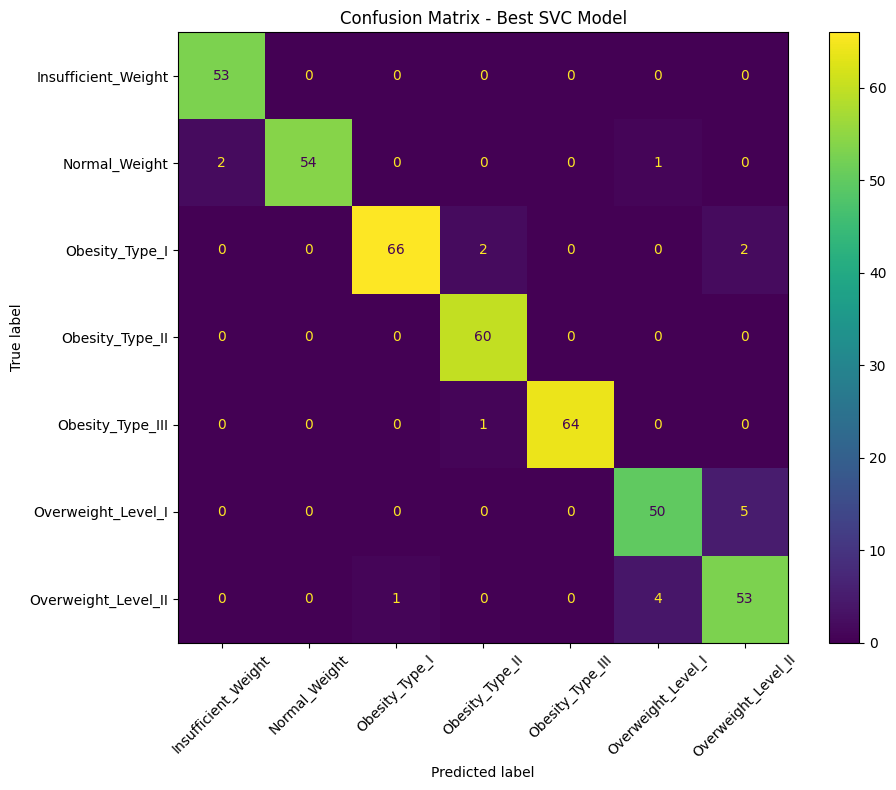

In [17]:
# ============================================
# 17. CONFUSION MATRIX
# ============================================
cm = confusion_matrix(y_test, y_pred, labels=best_model.classes_)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_model.classes_)
fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(ax=ax, xticks_rotation=45)
plt.title("Confusion Matrix - Best SVC Model")
plt.tight_layout()
plt.show()

In [18]:
# ============================================
# 18. VIEW CV RESULTS
# ============================================
cv_results = pd.DataFrame(grid_search.cv_results_)
display(
    cv_results[
        [
            "params",
            "mean_test_score",
            "std_test_score",
            "rank_test_score"
        ]
    ].sort_values("rank_test_score").head(10)
)

,params,mean_test_score,std_test_score,rank_test_score
20,"{'classifier__C': 10, 'classifier__gamma': 0.0...",0.964052,0.008461,1
22,"{'classifier__C': 10, 'classifier__gamma': 0.1...",0.964052,0.008461,1
18,"{'classifier__C': 10, 'classifier__gamma': 'au...",0.964052,0.008461,1
16,"{'classifier__C': 10, 'classifier__gamma': 'sc...",0.964052,0.008461,1
29,"{'classifier__C': 50, 'classifier__gamma': 0.0...",0.958055,0.012139,5
27,"{'classifier__C': 50, 'classifier__gamma': 'au...",0.956255,0.011485,6
26,"{'classifier__C': 50, 'classifier__gamma': 'au...",0.955056,0.010916,7
24,"{'classifier__C': 50, 'classifier__gamma': 'sc...",0.955056,0.010916,7
28,"{'classifier__C': 50, 'classifier__gamma': 0.0...",0.955056,0.010916,7
30,"{'classifier__C': 50, 'classifier__gamma': 0.1...",0.955056,0.010916,7


In [19]:
# ============================================
# 19. EXPORT THE BEST MODEL
# ============================================
joblib.dump(best_model, "best_svc_obesity_model.pkl")
print("Model exported as best_svc_obesity_model.pkl")

Model exported as best_svc_obesity_model.pkl
